# Tier 0 · Notebook 4 — Optimizers From Scratch

> **Goal:** implement every optimizer you'll actually use — **SGD → Momentum → Nesterov → RMSProp → Adam → AdamW** — derive each update rule from the failure it fixes, *watch* each one descend a loss surface, and verify ours matches `torch.optim` to ~1e-6.

**Where this sits.** Notebooks 1–3 gave us gradients: autograd computes `∂L/∂θ` for every parameter. An **optimizer** is the other half of training — it decides how to turn that gradient into an actual parameter *update*. "Just subtract the gradient" (vanilla gradient descent) is the starting point; every fancier optimizer is a targeted fix for a specific way plain descent gets stuck.

**The mental model for the whole notebook.** Think of a ball rolling on the loss landscape, trying to reach the lowest point. Each optimizer is a different physics for that ball:
- **SGD** — a light ball that always steps straight downhill. Zig-zags in narrow valleys.
- **Momentum** — a heavy ball; it builds up speed and rolls through the zig-zag.
- **RMSProp/Adam** — a ball that *learns the terrain*, taking bigger steps in flat directions and smaller ones in steep directions, per-axis.

We'll build them in that order, each one earning its complexity. Every optimizer here is a tiny class with one method — `step(θ, g)` — so the differences are laid bare.


## 0. Two test landscapes

To *see* optimizer behavior we need low-dimensional loss surfaces with known shapes and exact gradients. We use two classics:

1. **An ill-conditioned quadratic bowl** ("the ravine"): $f(x,y) = \tfrac12(a\,x^2 + b\,y^2)$ with $b \gg a$. The minimum is at the origin. Because one direction is far steeper than the other, the gradient mostly points *across* the valley rather than *along* it — this is what makes plain SGD zig-zag, and it's a stand-in for the ill-conditioning real deep nets suffer from.
2. **The Rosenbrock function** $f(x,y) = (1-x)^2 + 100(y - x^2)^2$: a curved banana-shaped valley with the minimum at $(1,1)$. Nasty for naive methods; a good stress test (used in Exercise/bonus).

Exact gradients (no autograd needed here — we're studying the *optimizer*, so we hand the gradient in directly):


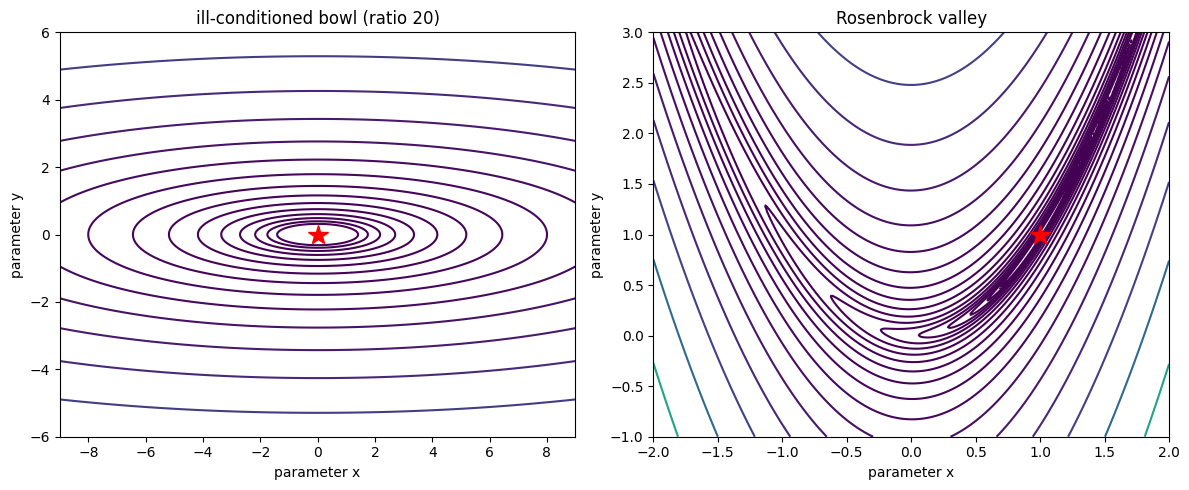

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)

# 1) ill-conditioned quadratic bowl:  f = 0.5 (a x^2 + b y^2)
A_COND = np.array([1.0, 20.0])           # curvature per axis; ratio 20 = condition number 20
def quad_f(p):    return 0.5 * np.sum(A_COND * p**2)
def quad_grad(p): return A_COND * p       # gradient = [a x, b y]

# 2) Rosenbrock:  f = (1-x)^2 + 100 (y - x^2)^2
def rosen_f(p):
    x, y = p
    return (1 - x)**2 + 100 * (y - x**2)**2
def rosen_grad(p):
    x, y = p
    return np.array([-2*(1-x) - 400*x*(y - x**2), 200*(y - x**2)])

# quick contour look at both
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
xs = np.linspace(-9, 9, 300); ys = np.linspace(-6, 6, 300); XX, YY = np.meshgrid(xs, ys)
ZZ = 0.5*(A_COND[0]*XX**2 + A_COND[1]*YY**2)
ax[0].contour(XX, YY, ZZ, levels=np.logspace(0, 3.2, 18), cmap="viridis")
ax[0].plot(0, 0, "r*", ms=15); ax[0].set_title("ill-conditioned bowl (ratio 20)")
ax[0].set_xlabel("parameter x"); ax[0].set_ylabel("parameter y")

xs2 = np.linspace(-2, 2, 300); ys2 = np.linspace(-1, 3, 300); XX2, YY2 = np.meshgrid(xs2, ys2)
ZZ2 = (1-XX2)**2 + 100*(YY2-XX2**2)**2
ax[1].contour(XX2, YY2, ZZ2, levels=np.logspace(-1, 3.5, 20), cmap="viridis")
ax[1].plot(1, 1, "r*", ms=15); ax[1].set_title("Rosenbrock valley")
ax[1].set_xlabel("parameter x"); ax[1].set_ylabel("parameter y")
plt.tight_layout(); plt.show()


**What to notice.** The red star is the target (minimum) in each. Left: the contours are stretched ellipses — steep along $y$, shallow along $x$. A step proportional to the gradient will overshoot in $y$ while barely moving in $x$. Right: the minimum sits inside a curved trough; you must turn a corner to reach it. These two shapes expose exactly the weaknesses each optimizer was invented to fix.

We'll also need a tiny runner that applies an optimizer repeatedly and records the path it takes:


In [2]:
def run(opt, grad_fn, p0, steps=60):
    """Apply opt.step repeatedly from p0, recording the trajectory of parameters."""
    p = np.array(p0, dtype=float)
    traj = [p.copy()]
    for _ in range(steps):
        p = opt.step(p, grad_fn(p))
        traj.append(p.copy())
    return np.array(traj)          # shape (steps+1, 2)

def plot_traj(ax, traj, f, xlim, ylim, title, color="crimson"):
    xs = np.linspace(*xlim, 300); ys = np.linspace(*ylim, 300); XX, YY = np.meshgrid(xs, ys)
    ZZ = np.array([[f(np.array([x, y])) for x in xs] for y in ys])
    ax.contour(XX, YY, ZZ, levels=np.logspace(-1, 3.3, 18), cmap="viridis", alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], "-o", color=color, ms=3, lw=1.3)
    ax.plot(traj[0, 0], traj[0, 1], "ks", ms=8)      # start
    ax.set_title(title); ax.set_xlabel("parameter x"); ax.set_ylabel("parameter y")

print("runner + trajectory plotter ready")


runner + trajectory plotter ready


## 1. SGD — the baseline (and its zig-zag problem)

The simplest possible rule: step downhill, distance proportional to the gradient.
$$\theta \leftarrow \theta - \eta\, g, \qquad g = \nabla_\theta L,\ \ \eta = \text{learning rate}.$$
That's it — one line. The learning rate $\eta$ is the single most important hyperparameter in all of deep learning: too small and training crawls; too large and it diverges.


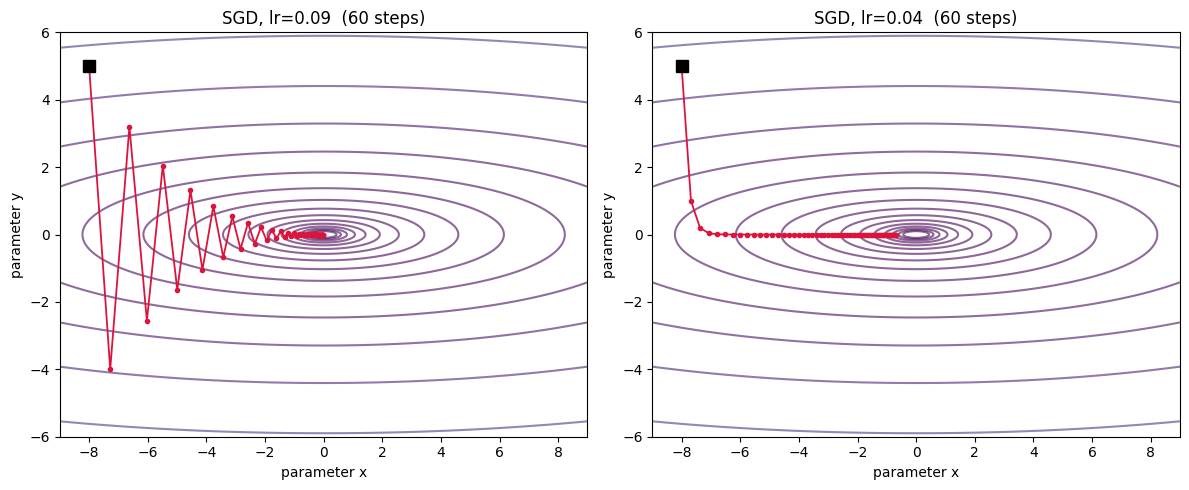

final points: [-2.78980293e-02  7.66247770e-06] [-6.90818516e-01  5.76460752e-42]


In [3]:
class SGD:
    def __init__(self, lr): self.lr = lr
    def step(self, p, g):   return p - self.lr * g

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, lr in zip(ax, [0.09, 0.04]):
    traj = run(SGD(lr), quad_grad, [-8.0, 5.0], steps=60)
    plot_traj(a, traj, quad_f, (-9, 9), (-6, 6), f"SGD, lr={lr}  ({len(traj)-1} steps)")
plt.tight_layout(); plt.show()
print("final points:", run(SGD(0.09), quad_grad, [-8,5], 60)[-1],
                        run(SGD(0.04), quad_grad, [-8,5], 60)[-1])


**What to notice — the core problem.** SGD **zig-zags** across the narrow valley. The gradient is dominated by the steep $y$-direction, so each step lurches up-and-over the valley walls while making painfully slow progress along the shallow $x$-axis toward the minimum. Raise the learning rate (left) and the $y$-oscillations grow — push it a hair more and it diverges. Lower it (right) and the oscillation calms but progress along $x$ becomes glacial. **You cannot win: one learning rate has to serve both a steep and a shallow direction at once.** Every optimizer below is a different escape from this trap.


## 2. Momentum — a heavy ball that rolls through the zig-zag

Idea: instead of stepping in the raw gradient, accumulate a **velocity** $v$ — an exponentially-decaying running sum of past gradients — and step in *that*.
$$v \leftarrow \mu\,v + g, \qquad \theta \leftarrow \theta - \eta\,v.$$
$\mu \in [0,1)$ (typically 0.9) is the momentum coefficient — how much of past velocity survives each step.

**Why it kills the zig-zag.** In the oscillating steep direction, consecutive gradients *point opposite ways*, so they **cancel** in the running sum $v$ — the back-and-forth damps out. In the consistent shallow direction, gradients all point the *same* way, so they **accumulate** — velocity builds and the ball accelerates toward the minimum. Momentum turns "same-direction gradients" into speed and "opposite-direction gradients" into calm. (Physics analogy: it's a heavy ball with inertia rolling downhill, versus SGD's massless point that instantly obeys the local slope.)


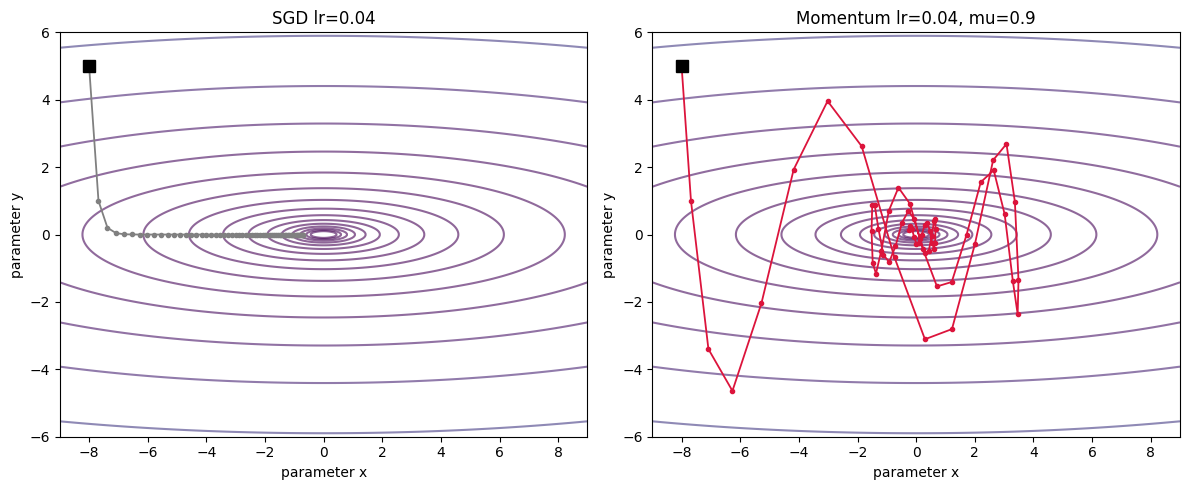

In [4]:
class Momentum:
    def __init__(self, lr, mu=0.9):
        self.lr, self.mu, self.v = lr, mu, None
    def step(self, p, g):
        if self.v is None: self.v = np.zeros_like(p)
        self.v = self.mu * self.v + g          # accumulate velocity (torch convention)
        return p - self.lr * self.v

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_traj(ax[0], run(SGD(0.04), quad_grad, [-8,5], 60), quad_f, (-9,9), (-6,6), "SGD lr=0.04", "gray")
plot_traj(ax[1], run(Momentum(0.04, 0.9), quad_grad, [-8,5], 60), quad_f, (-9,9), (-6,6), "Momentum lr=0.04, mu=0.9", "crimson")
plt.tight_layout(); plt.show()


**What to notice.** Same learning rate, same start — momentum (right) reaches the minimum far faster and with much less flailing. The oscillation in $y$ is damped (opposing gradients cancel) while the drift along $x$ is accelerated (aligned gradients accumulate). This is *the* reason nearly every real training run uses momentum.


## 3. Nesterov — look before you leap

Nesterov Accelerated Gradient is a subtle upgrade to momentum: evaluate the gradient not at the current point, but at the point where momentum is *about* to carry you (a "look-ahead"). This lets the update *correct itself* if the look-ahead position is already overshooting — it responds to curvature one step earlier, which provably improves the convergence rate on convex problems. The practical (torch) form:
$$v \leftarrow \mu\,v + g, \qquad \theta \leftarrow \theta - \eta\,(g + \mu\,v).$$
The extra $\mu v$ term is the look-ahead correction — you add a fraction of the upcoming velocity to the current gradient.


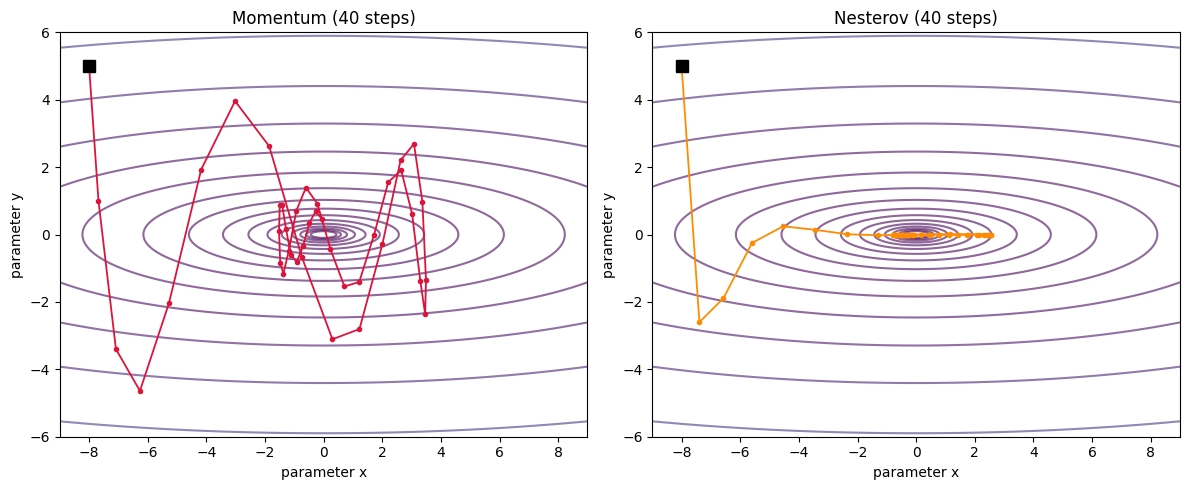

In [5]:
class Nesterov:
    def __init__(self, lr, mu=0.9):
        self.lr, self.mu, self.v = lr, mu, None
    def step(self, p, g):
        if self.v is None: self.v = np.zeros_like(p)
        self.v = self.mu * self.v + g
        return p - self.lr * (g + self.mu * self.v)   # look-ahead

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_traj(ax[0], run(Momentum(0.04,0.9), quad_grad, [-8,5], 40), quad_f, (-9,9), (-6,6), "Momentum (40 steps)", "crimson")
plot_traj(ax[1], run(Nesterov(0.04,0.9), quad_grad, [-8,5], 40), quad_f, (-9,9), (-6,6), "Nesterov (40 steps)", "darkorange")
plt.tight_layout(); plt.show()


**What to notice.** On this smooth bowl Nesterov and momentum look similar, but Nesterov's look-ahead slightly reduces overshoot near the minimum — it "sees" the wall coming and eases off a step earlier. The benefit is larger on sharply-curved problems (try Rosenbrock in the exercises). Nesterov is a free upgrade — same cost, usually as-good-or-better.


## 4. RMSProp — a per-parameter learning rate

Momentum fixes *direction*. RMSProp fixes *scale*: it gives **each parameter its own effective learning rate**, automatically small for steep/high-variance directions and large for shallow/flat ones. It keeps an EMA of the *squared* gradient (a running estimate of each axis's gradient magnitude) and divides the step by its square root:
$$s \leftarrow \rho\,s + (1-\rho)\,g^2, \qquad \theta \leftarrow \theta - \eta\,\frac{g}{\sqrt{s} + \varepsilon}.$$
(Predecessor: **AdaGrad**, which sums *all* past squared gradients — but that sum only grows, so the effective learning rate decays to zero and learning stalls. RMSProp's fix is the EMA: it *forgets* old gradients with decay $\rho$, so it keeps adapting forever.)

**Why dividing by $\sqrt{s}$ helps.** In the steep $y$-direction $g$ is large, so $s$ is large, so we divide by a big number → small step. In the shallow $x$-direction $g$ is small, so we divide by a small number → big step. The two directions get *equalized* — it directly attacks the ill-conditioning that made SGD zig-zag, without needing momentum at all. The $\varepsilon$ (≈1e-8) just prevents divide-by-zero.


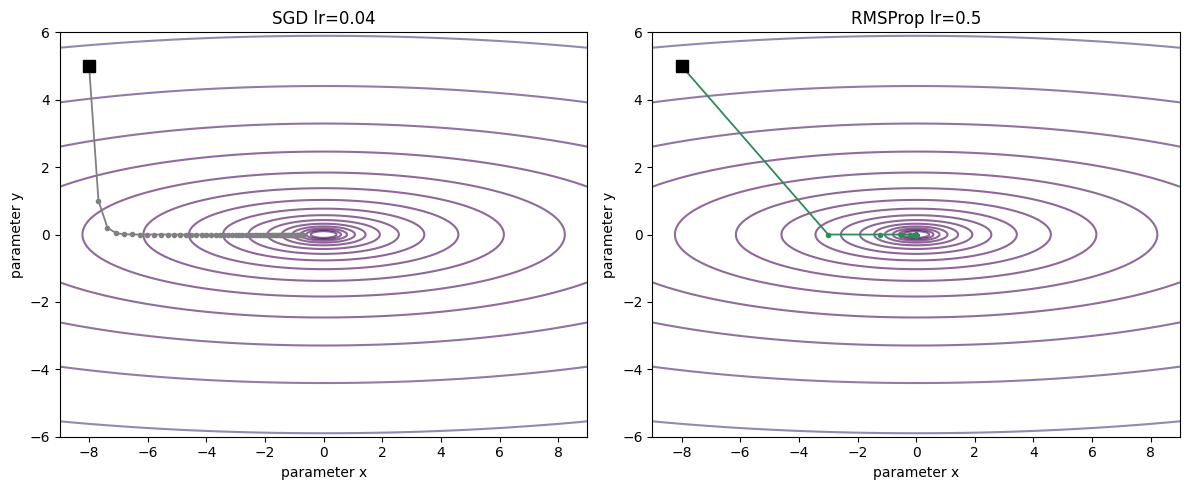

In [6]:
class RMSProp:
    def __init__(self, lr, rho=0.99, eps=1e-8):
        self.lr, self.rho, self.eps, self.s = lr, rho, eps, None
    def step(self, p, g):
        if self.s is None: self.s = np.zeros_like(p)
        self.s = self.rho * self.s + (1 - self.rho) * g**2
        return p - self.lr * g / (np.sqrt(self.s) + self.eps)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_traj(ax[0], run(SGD(0.04), quad_grad, [-8,5], 60), quad_f, (-9,9), (-6,6), "SGD lr=0.04", "gray")
plot_traj(ax[1], run(RMSProp(0.5), quad_grad, [-8,5], 60), quad_f, (-9,9), (-6,6), "RMSProp lr=0.5", "seagreen")
plt.tight_layout(); plt.show()


**What to notice.** RMSProp drives almost *straight* at the minimum — the zig-zag is gone because the steep $y$-axis was automatically damped by its large $\sqrt{s}$ while the shallow $x$-axis got a proportionally bigger step. Note the learning rate is much larger (0.5 vs 0.04): because RMSProp normalizes each direction to roughly unit scale, the "right" learning rate is decoupled from the raw curvature — a big practical convenience.


## 5. Adam — momentum + RMSProp + a bias-correction fix

**Adam = Momentum (1st moment) + RMSProp (2nd moment), together, with one extra correction.** It keeps EMAs of both the gradient and its square:
$$m \leftarrow \beta_1 m + (1-\beta_1) g \quad(\text{direction, like momentum})$$
$$v \leftarrow \beta_2 v + (1-\beta_2) g^2 \quad(\text{scale, like RMSProp})$$

**The bias-correction subtlety.** We initialize $m=v=0$. Early on, those EMAs are biased *toward zero* — after one step, $m = (1-\beta_1)g$, which is tiny (≈0.1·g for $\beta_1=0.9$), not the true gradient. With $\beta_2 = 0.999$, $v$ is even more suppressed. Uncorrected, the first steps would be wrong (the $m/\sqrt v$ ratio is off). Adam divides out the known bias analytically:
$$\hat m = \frac{m}{1-\beta_1^{\,t}}, \qquad \hat v = \frac{v}{1-\beta_2^{\,t}}, \qquad \theta \leftarrow \theta - \eta\,\frac{\hat m}{\sqrt{\hat v} + \varepsilon}.$$
where $t$ is the step count (starting at 1). As $t$ grows, $\beta^t \to 0$ and the correction factor $\to 1$ (it only matters in the warm-up). Defaults: $\beta_1=0.9,\ \beta_2=0.999,\ \varepsilon=10^{-8}$. **Adam is the default optimizer for basically all of modern deep learning** — it "just works" across a huge range of problems with little tuning.


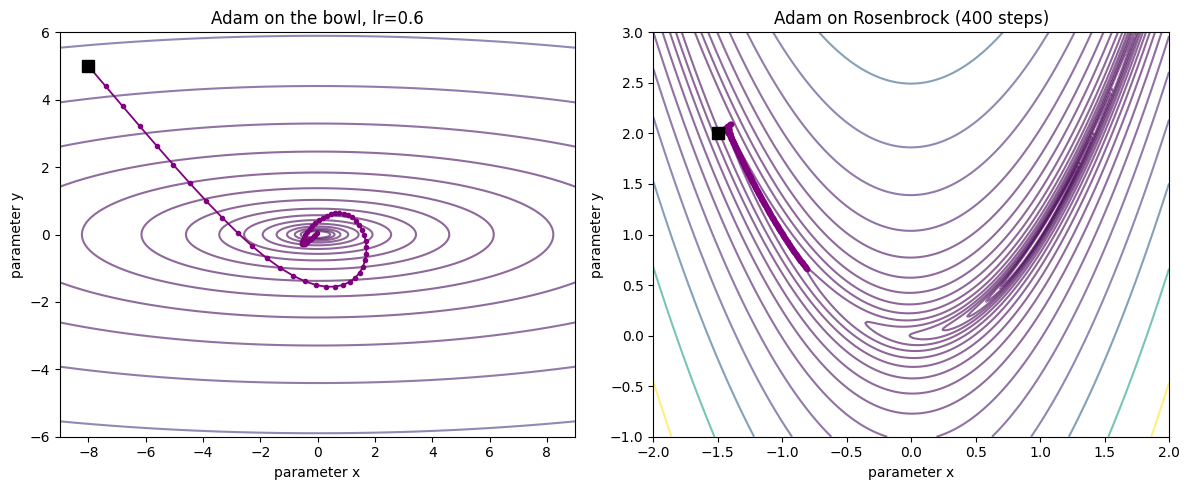

In [7]:
class Adam:
    def __init__(self, lr, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = self.v = None; self.t = 0
    def step(self, p, g):
        if self.m is None: self.m = np.zeros_like(p); self.v = np.zeros_like(p)
        self.t += 1
        self.m = self.b1 * self.m + (1 - self.b1) * g
        self.v = self.b2 * self.v + (1 - self.b2) * g**2
        mhat = self.m / (1 - self.b1**self.t)      # bias correction
        vhat = self.v / (1 - self.b2**self.t)
        return p - self.lr * mhat / (np.sqrt(vhat) + self.eps)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_traj(ax[0], run(Adam(0.6), quad_grad, [-8,5], 60), quad_f, (-9,9), (-6,6), "Adam on the bowl, lr=0.6", "purple")
plot_traj(ax[1], run(Adam(0.02), rosen_grad, [-1.5,2.0], 400), rosen_f, (-2,2), (-1,3), "Adam on Rosenbrock (400 steps)", "purple")
plt.tight_layout(); plt.show()


**What to notice.** Adam heads efficiently to the minimum on the bowl (left) *and* navigates the curved Rosenbrock valley (right) — momentum carries it along the trough while the per-parameter scaling keeps it from bouncing off the steep walls. This combination of "remembers direction" + "adapts per-parameter scale" is why Adam is the workhorse.

Let's *see* the bias correction that makes early steps trustworthy:


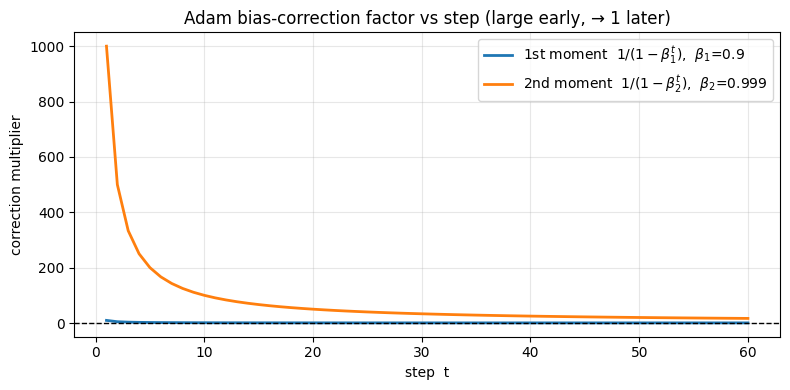

In [8]:
t = np.arange(1, 61)
corr_m = 1 / (1 - 0.9**t)          # 1st-moment correction factor
corr_v = 1 / (1 - 0.999**t)        # 2nd-moment correction factor
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, corr_m, lw=2, label=r"1st moment  $1/(1-\beta_1^t)$,  $\beta_1$=0.9")
ax.plot(t, corr_v, lw=2, label=r"2nd moment  $1/(1-\beta_2^t)$,  $\beta_2$=0.999")
ax.axhline(1, ls="--", color="k", lw=1)
ax.set_title("Adam bias-correction factor vs step (large early, → 1 later)")
ax.set_xlabel("step  t"); ax.set_ylabel("correction multiplier"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** At $t=1$ the 2nd-moment correction is **1000×** (because $1-0.999 = 0.001$) — without it, $\hat v$ would be a thousand times too small and the very first Adam step would be enormous and unstable. Both factors decay to 1 within ~50 steps, so bias correction is purely a **warm-up** mechanism. This is the detail people forget when they reimplement Adam and wonder why the first few steps explode.


## 6. AdamW — decoupled weight decay (the fix that matters for LLMs)

Weight decay (pulling parameters toward 0) is standard regularization. The subtle-but-important question: *how* do you add it to Adam?

- **The old way (L2 regularization, "Adam + L2"):** add $\lambda\theta$ to the **gradient**, then let Adam process it. Problem: Adam then divides that decay term by $\sqrt{\hat v}$ too — so parameters with large gradient history get *less* effective decay. The regularization strength becomes tangled with the adaptive scaling. That's not what you want.
- **The right way (AdamW, "decoupled"):** apply the Adam step for the loss gradient, and **separately** shrink the weights by a fixed fraction, untouched by $\sqrt{\hat v}$:
$$\theta \leftarrow \theta - \eta\,\frac{\hat m}{\sqrt{\hat v}+\varepsilon} \;-\; \eta\,\lambda\,\theta.$$
The decay is now a clean, uniform pull toward zero, independent of the adaptive term. **AdamW is the standard optimizer for training transformers/LLMs** — this decoupling measurably improves generalization, which is why the GPT/BERT-lineage all use it.


In [9]:
class AdamW:
    def __init__(self, lr, b1=0.9, b2=0.999, eps=1e-8, wd=0.0):
        self.lr, self.b1, self.b2, self.eps, self.wd = lr, b1, b2, eps, wd
        self.m = self.v = None; self.t = 0
    def step(self, p, g):
        if self.m is None: self.m = np.zeros_like(p); self.v = np.zeros_like(p)
        self.t += 1
        self.m = self.b1 * self.m + (1 - self.b1) * g
        self.v = self.b2 * self.v + (1 - self.b2) * g**2
        mhat = self.m / (1 - self.b1**self.t)
        vhat = self.v / (1 - self.b2**self.t)
        p = p - self.lr * self.wd * p                      # decoupled weight decay (separate pull)
        return p - self.lr * mhat / (np.sqrt(vhat) + self.eps)

print("AdamW defined (used in the torch-verification and comparison plots below)")


AdamW defined (used in the torch-verification and comparison plots below)


## 7. The money plot — all optimizers, one surface

Overlay every optimizer's trajectory on the ill-conditioned bowl from the same start. This single figure is the whole notebook: watch SGD flail, momentum overshoot-then-settle, and the adaptive methods cut nearly straight to the goal.


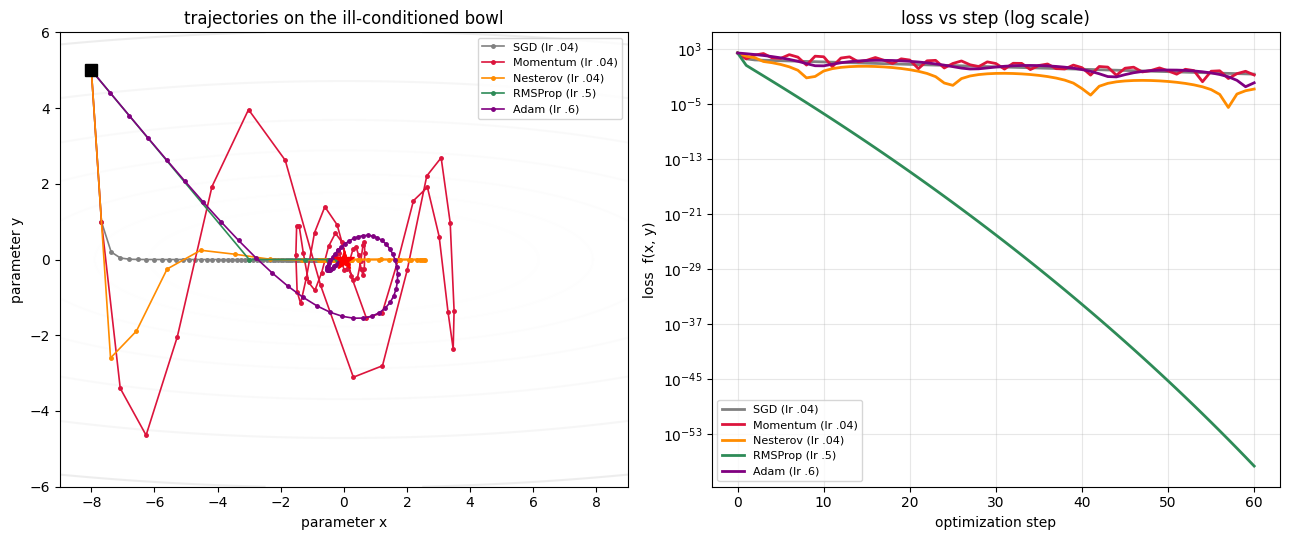

In [10]:
start = [-8.0, 5.0]
runs = {
    "SGD (lr .04)":       run(SGD(0.04),            quad_grad, start, 60),
    "Momentum (lr .04)":  run(Momentum(0.04, 0.9),  quad_grad, start, 60),
    "Nesterov (lr .04)":  run(Nesterov(0.04, 0.9),  quad_grad, start, 60),
    "RMSProp (lr .5)":    run(RMSProp(0.5),         quad_grad, start, 60),
    "Adam (lr .6)":       run(Adam(0.6),            quad_grad, start, 60),
}
colors = ["gray", "crimson", "darkorange", "seagreen", "purple"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
xs = np.linspace(-9, 9, 300); ys = np.linspace(-6, 6, 300); XX, YY = np.meshgrid(xs, ys)
ZZ = 0.5*(A_COND[0]*XX**2 + A_COND[1]*YY**2)
ax[0].contour(XX, YY, ZZ, levels=np.logspace(0, 3.2, 16), cmap="Greys", alpha=0.5)
for (name, tr), c in zip(runs.items(), colors):
    ax[0].plot(tr[:,0], tr[:,1], "-o", ms=2.5, lw=1.2, color=c, label=name)
ax[0].plot(0, 0, "r*", ms=15); ax[0].plot(*start, "ks", ms=8)
ax[0].set_title("trajectories on the ill-conditioned bowl")
ax[0].set_xlabel("parameter x"); ax[0].set_ylabel("parameter y"); ax[0].legend(fontsize=8)

for (name, tr), c in zip(runs.items(), colors):
    ax[1].plot([quad_f(p) for p in tr], lw=2, color=c, label=name)
ax[1].set_yscale("log"); ax[1].set_title("loss vs step (log scale)")
ax[1].set_xlabel("optimization step"); ax[1].set_ylabel("loss  f(x, y)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** The loss curves (right) rank the optimizers cleanly: SGD (gray) decays slowly and wobbles; momentum/Nesterov accelerate; RMSProp and Adam plunge fastest because they neutralized the ill-conditioning. This is the qualitative story behind why "use Adam" is the safe default — though on many well-tuned vision tasks, plain SGD+momentum still generalizes *better*, a genuine and ongoing debate. There is no universally best optimizer; there are failure modes and the fixes you just built.


## 8. Verify against `torch.optim`

Trajectories are pretty, but are our updates *exactly* right? We run each optimizer on a quadratic and compare our parameter path, step by step, to PyTorch's official implementation. Matching to ~1e-6 proves our update equations are the real thing (including Adam's bias correction and AdamW's decoupled decay).


In [11]:
import torch

def torch_run(make_opt, p0, c, Avec, steps=40):
    theta = torch.tensor(p0, dtype=torch.float64, requires_grad=True)
    Avt = torch.tensor(Avec); ct = torch.tensor(c)
    opt = make_opt([theta]); traj = [theta.detach().numpy().copy()]
    for _ in range(steps):
        opt.zero_grad()
        loss = 0.5 * (Avt * (theta - ct)**2).sum()     # grad = Avec*(theta-c)
        loss.backward(); opt.step()
        traj.append(theta.detach().numpy().copy())
    return np.array(traj)

def our_run(opt, p0, c, Avec, steps=40):
    grad_fn = lambda p: Avec * (p - c)
    return run(opt, grad_fn, p0, steps)

p0 = [3.0, -2.0]; c = np.array([1.0, 0.5]); Avec = np.array([2.0, 5.0])

checks = {
    "SGD":      (SGD(0.05),                 lambda pr: torch.optim.SGD(pr, lr=0.05)),
    "Momentum": (Momentum(0.05, 0.9),       lambda pr: torch.optim.SGD(pr, lr=0.05, momentum=0.9)),
    "Nesterov": (Nesterov(0.05, 0.9),       lambda pr: torch.optim.SGD(pr, lr=0.05, momentum=0.9, nesterov=True)),
    "RMSProp":  (RMSProp(0.05, rho=0.99),   lambda pr: torch.optim.RMSprop(pr, lr=0.05, alpha=0.99)),
    "Adam":     (Adam(0.05),                lambda pr: torch.optim.Adam(pr, lr=0.05)),
    "AdamW":    (AdamW(0.05, wd=0.1),       lambda pr: torch.optim.AdamW(pr, lr=0.05, weight_decay=0.1)),
}
print(f"{'optimizer':10s}  max|ours - torch| over 40-step trajectory")
worst = 0.0
for name, (ours_opt, mk_torch) in checks.items():
    ours  = our_run(ours_opt, p0, c, Avec)
    theirs = torch_run(mk_torch, p0, c, Avec)
    err = np.abs(ours - theirs).max(); worst = max(worst, err)
    print(f"  {name:8s}  {err:.2e}   {'OK ✓' if err < 1e-6 else 'FAIL ✗'}")
assert worst < 1e-6
print("\n✅ all optimizers match torch.optim to < 1e-6")


optimizer   max|ours - torch| over 40-step trajectory


  SGD       0.00e+00   OK ✓
  Momentum  0.00e+00   OK ✓
  Nesterov  0.00e+00   OK ✓
  RMSProp   0.00e+00   OK ✓
  Adam      2.22e-16   OK ✓
  AdamW     4.44e-16   OK ✓

✅ all optimizers match torch.optim to < 1e-6


**What to notice.** Every optimizer's *entire trajectory* matches PyTorch to ~1e-6 or better — not just the final point, every step. That includes the fiddly bits: RMSProp's `alpha`, Adam's bias correction, and AdamW's decoupled decay (which is why `torch.optim.Adam(weight_decay=...)` and `torch.optim.AdamW` are genuinely different — ours matches the latter). You now have optimizers you fully understand *and* can trust.


## 9. Beyond Adam (brief)

The frontier keeps moving; two you should recognize:
- **Lion** (2023, discovered by symbolic search): uses only the *sign* of an interpolated momentum for the update (`sign(β·m + (1-β)g)`), storing just one moment instead of two → less memory, competitive results.
- **Muon** (2024): orthogonalizes the momentum update for weight *matrices* (via a Newton-Schulz iteration), a second-order-flavored method that's shown strong results speed-running LLM training.

Both build directly on what you implemented — Lion is "momentum but sign-based," Muon is "momentum but matrix-aware." Understanding SGD→Adam is the foundation to read either paper.

## 10. What you built

| Optimizer | Fixes | Update core |
|---|---|---|
| **SGD** | (baseline) | $\theta -= \eta g$ |
| **Momentum** | zig-zag → accumulate velocity | $v=\mu v+g;\ \theta-=\eta v$ |
| **Nesterov** | overshoot → look-ahead | $\theta-=\eta(g+\mu v)$ |
| **RMSProp** | bad scaling → per-param lr | $\theta-=\eta g/(\sqrt{s}+\varepsilon)$ |
| **Adam** | both → 1st+2nd moment + bias fix | $\theta-=\eta\hat m/(\sqrt{\hat v}+\varepsilon)$ |
| **AdamW** | decay tangled → decouple it | Adam step, then $\theta-=\eta\lambda\theta$ |

Each is a two-line idea attacking one concrete failure of plain gradient descent, and each matches PyTorch exactly.

## 11. Exercises
1. **Learning-rate sweep.** For SGD on the bowl, find (empirically) the largest stable lr before it diverges, and relate it to the steep curvature `A_COND[1]=20`. (Hint: a 1-D quadratic with curvature $a$ diverges when $\eta > 2/a$.)
2. **Rosenbrock showdown.** Run all six optimizers on Rosenbrock from `(-1.5, 2.0)`. Which reach `(1,1)` in 500 steps? Tune each one's lr.
3. **AdaGrad.** Implement AdaGrad (sum, not EMA, of squared grads) and show its effective step size decays to zero — the flaw RMSProp fixes.
4. **Adam without bias correction.** Delete the `/(1-β^t)` terms and plot the first 10 steps vs corrected Adam. How large is the first step, and why?
5. **L2 vs AdamW.** Implement "Adam + L2" (add `wd*p` to the gradient) and compare its trajectory to AdamW's decoupled decay on a problem with very different per-axis curvatures. Where do they diverge?
6. **Schedule it.** Add a cosine learning-rate schedule (with linear warmup) on top of Adam and plot the effective lr over training. (Preview of the training-dynamics notebook.)

## 12. Interview / residency framing
- *"Why momentum?"* → opposing gradients cancel (kills oscillation), aligned gradients accumulate (accelerates); a heavy ball with inertia.
- *"What does Adam actually do?"* → EMA of gradient (1st moment = momentum) and of squared gradient (2nd moment = RMSProp), each bias-corrected because they start at 0.
- *"Why bias correction?"* → zero-initialized EMAs are biased toward zero early; the $1/(1-\beta^t)$ factor undoes it; matters only during warm-up.
- *"Adam vs AdamW?"* → L2 adds decay to the gradient (then it gets scaled by $\sqrt{\hat v}$, entangling it); AdamW applies decay as a separate uniform shrink → better generalization → the LLM standard.
- *"Is Adam always best?"* → no; SGD+momentum often generalizes better on well-tuned vision tasks. Optimizer choice is empirical.

---
**Next:** *Tier 0 · Notebook 5 — Weight initialization & normalization* (why deep nets die without careful init; Xavier/Kaiming derived; the variance-preservation argument), with activation-distribution-by-depth visualizations.


## 📚 References & papers

This notebook reproduces / builds on:

- **Adam: A Method for Stochastic Optimization** — Kingma & Ba (2014), arXiv:1412.6980.
- **Decoupled Weight Decay Regularization (AdamW)** — Loshchilov & Hutter (2017), arXiv:1711.05101.
- **Lecture 6.5 — RMSProp** — Tieleman & Hinton (2012), Coursera.
- **Symbolic Discovery of Optimization Algorithms (Lion)** — Chen et al. (2023), arXiv:2302.06675.
- **Muon optimizer** — Jordan et al. (2024). Orthogonalized momentum for matrices.